# Convolution filters
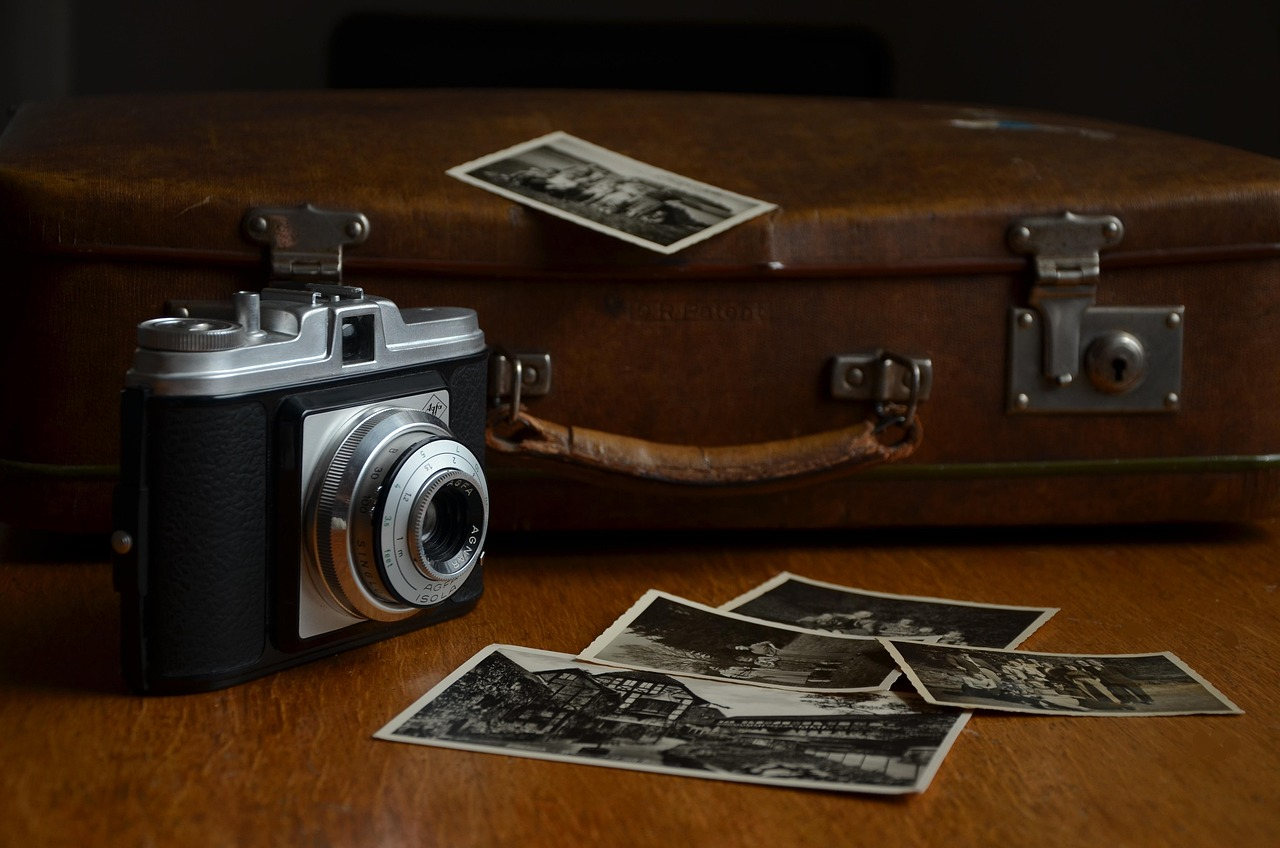

*Source: Pixabay*

## Introduction
Imagine finding old family photographs in the attic. Unfortunately, the passage of time has made the photos faded, noisy, and blurry. You want to restore them and bring back their former glory. You could spend many hours manually correcting them in a graphics program, but what if you could create one, universal "magic filter" that would automatically fix any damaged photo?

In this task, your goal is to create just such a "recipe" for repairing images. This recipe, in the world of computer science and artificial intelligence, is called a **convolution kernel**. It is a fundamental tool in image processing that underlies how computers "see" and understand the world.

## What is Convolution?

Before we get to the task, we need to understand two things: what an image is to a computer and how the "magic filter," i.e., convolution, works on it.

### What is an image to a computer?
For us, an image is a face, a landscape, or a cat. For a computer, it's simply a **large grid of numbers**. Each number in this grid corresponds to the brightness of a single **pixel**. In color images, we have three such grids – one for the color red (R), one for green (G), and one for blue (B).

### How does convolution work?
Convolution is an operation in which a small matrix of numbers (e.g., 3x3 in size), called a **kernel**, is moved across the entire image, pixel by pixel.

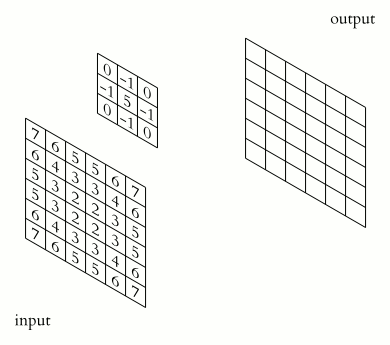

*Source: Michael Plotke, CC BY-SA 3.0 <https://creativecommons.org/licenses/by-sa/3.0>, via Wikimedia Commons*

For each position of the kernel on the image, we perform a simple operation:
1.  We take the fragment of the image located under the kernel and **multiply** the corresponding pixel values and the weights from the kernel.
2.  We **sum** all of these results.
3.  The result of this sum becomes the **new pixel value** in the new, processed image.

Depending on what numbers we write into the kernel, we will achieve completely different effects.

## Kernel examples

| Kernel (3x3 Matrix) | Image Effect |
|:---:|:---:|
| **Identity**<br>The one in the middle makes the new pixel a perfect copy of the original.<br> $$\begin{bmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0 \end{bmatrix}$$ | 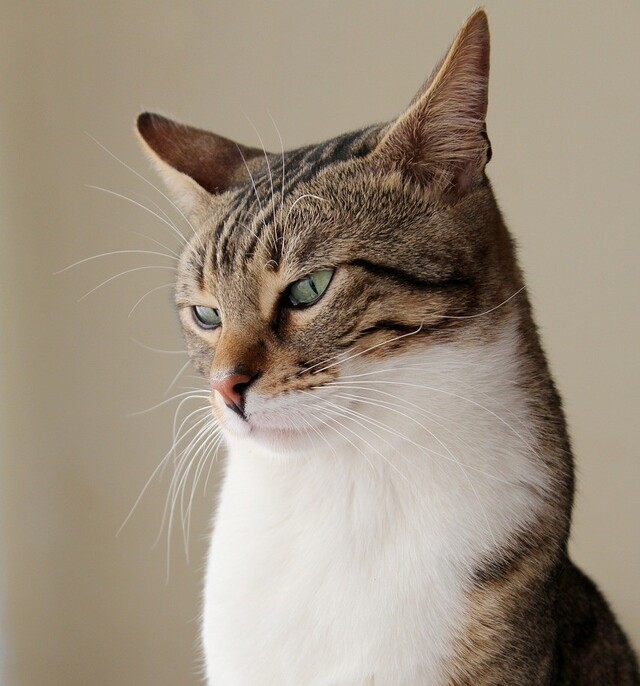 |
| **Blur**<br>Averages the pixel's value with its neighbors, which smooths the image.<br> $$\begin{bmatrix} \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\ \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\ \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \end{bmatrix}$$ | 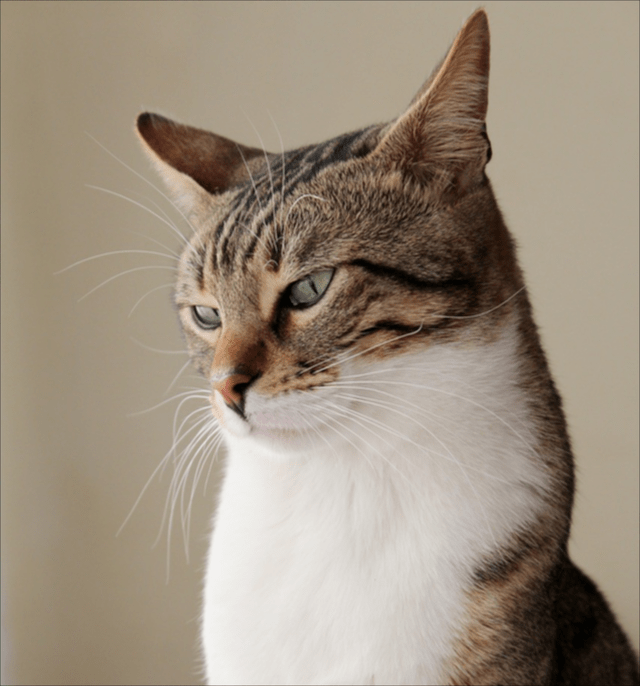 |
| **Sharpen**<br>Emphasizes the differences between a pixel and its surroundings, enhancing details.<br> $$\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$ | 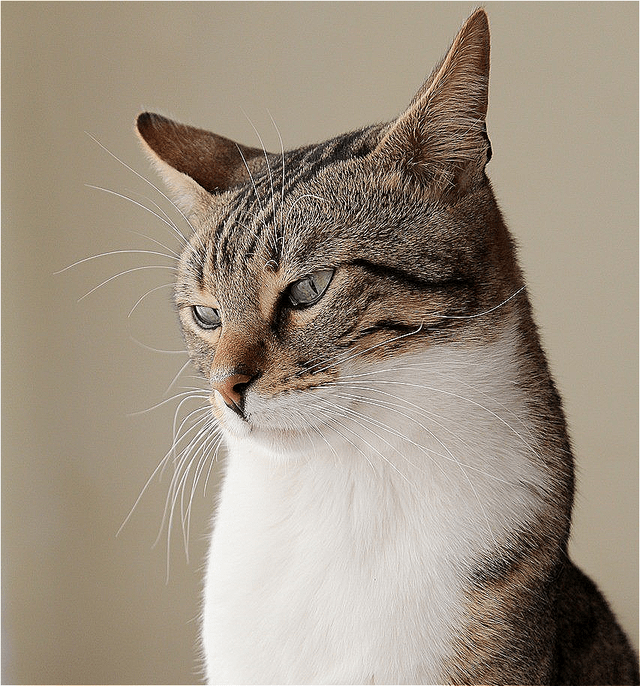 |
| **Vertical edge detection**<br>Enhances places where there are dark pixels on the left side and bright ones on the right.<br> $$\begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$ | 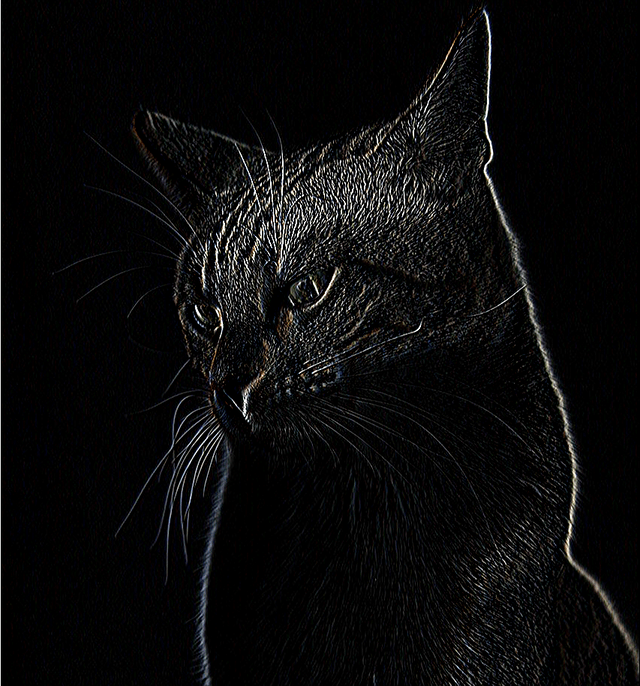 |


## And what is upsampling?

In the second part of the task, you will encounter the concept of **upsampling**, which is **enlarging an image**.
This is the opposite operation of downsizing (downsampling):
we have a small image, e.g., 128x128 pixels, and we want to obtain a larger one from it—e.g., 256x256.

The problem is that the computer doesn't know what the values of the new, "invented" pixels should be.
Therefore, it has to **guess** them somehow.

The simplest way is to devise a very simple rule, for example, this one (called **nearest neighbor upsampling**):

> Each pixel from the small image is simply **duplicated** horizontally and vertically as many times as needed to fill a larger block of pixels.

As a result, the enlarged image looks like a magnified "mosaic"—the shapes are preserved, but sharp edges and large pixels are clearly visible.

## Task

In this task, you will work on two related parts:

1.  Part One — Convolutional Kernel
2.  Part Two — Upsampling (image enlargement)

Each of them is graded independently.

### Part 1 — Convolutional Kernel

Your task is to find **one, universal kernel (filter)**
that can restore damaged photos to a form as close as possible to the originals.

*Note:* The kernel size should not exceed **10x10**.

As a starting point, you receive the `compute_kernel()` function,
which returns a simple filter—a so-called **9x9 blurring kernel** (you can find an example showing the operation of such a kernel in a 3x3 size above).

Instead of manually selecting the weights, you can use the `autograd` mechanism from the PyTorch library. It is used for automatic optimization—in an iterative process, it will adjust the values in the kernel so that the image reconstruction error is as small as possible.

### Part 2 — Upsampling

In the second part, you will focus on the problem of image enlargement.

This time your task is to implement the `upsample(image: torch.Tensor) -> torch.Tensor` function,
which receives a downsized image (`(C, h, w)`) and is supposed to enlarge it to the full size (`(C, H, W)`).

The reference point (baseline) will be a very simple method,
**nearest neighbor**, which duplicates each pixel the appropriate number of times vertically and horizontally.

In addition to the `upsample` function, you also have the option to define an **additional kernel** (calculated by the `compute_kernel_upsampling(kernel_task1: torch.Tensor) -> torch.Tensor` function), which will be applied *after* upsampling, on the already enlarged image. By default, this is the kernel from the first part of the task.

In this part, the quality of the image reconstruction is evaluated after two stages:

1.  **upsampling (the `upsample()` function)**,
2.  **convolution with your kernel (the `compute_kernel_upsampling(...)` function)**.

## Data

In this task, two datasets are available to you, stored in a single file (`train_val.npz`):

*   `train_ds` — **150 training examples**,
*   `val_ds` — **50 validation examples**.

Each example is a **triplet of related images**:

*   `image_original` – the original, correct image with a resolution of **256x256 pixels**,
*   `image_corrupted` – the same image after distortion, also **256x256**,
*   `image_corrupted_downsampled` – a version of `image_corrupted` downsampled to **128x128**,
    on which you will test your upsampling methods.

All images are color (RGB) and stored as **PyTorch tensors** with a shape of `(3, H, W)`
and values normalized to the range **[0, 1]**.

## Evaluation Criteria
Both parts of the task will be evaluated based on the **MSE (Mean Squared Error)** metric. This is a simple way to measure how much two images differ from each other. This metric calculates the difference between each pixel in the reconstructed image and the original, squares these differences, and then takes their average.

**The lower the MSE value, the more similar the images are, and the better your solution is.**

### Part 1 (70 pts.) - Convolutional Kernel
- You can score a maximum of 70 points for this part.
- If the MSE value for your solution is 0.0285 (or more), you will receive 0 points for this part of the task.
- If the MSE value for your solution is 0.0077 (or less), you will receive 70 points for this part of the task.
- Otherwise, the number of points will be determined proportionally to the MSE value:
$$
\text{score} \_ \text{kernel} = round(\frac{0.0285 - \text{MSE} \_ \text{kernel}}{0.0285 - 0.0077} \times 70)
$$

### Part 2 (30 pts.) - Upsampling
- You can score a maximum of 30 points for this part.
- If the MSE value for your solution is 0.0542 (or more), you will receive 0 points for this part of the task.
- If the MSE value for your solution is 0.0350 (or less), you will receive 30 points for this part of the task.
- Otherwise, the number of points will be determined proportionally to the MSE value:
$$
\text{score} \_ \text{upsampling} = round(\frac{0.0542 - \text{MSE} \_ \text{upsampling}}{0.0542 - 0.0350} \times 30)
$$

### Final Score

The final score is the sum of the scores from both parts:
$$
\text{Final Score} = \text{score} \_ \text{kernel} + \text{score} \_ \text{upsampling}
$$
meaning:
- **70% of the points** come from the quality of your kernel (the `compute_kernel()` function)
- **30% of the points** come from the quality of your `upsample()` and `compute_kernel_upsampling()` functions.

## Constraints
- Your solution will be tested on the Competition Platform without internet access and in an environment with a GPU.
- The evaluation of your final solution on the Competition Platform cannot take longer than 3.5 minutes with a GPU.
- Allowed libraries: `numpy`, `torch` (in the solution, you **cannot** use the `torch.nn` module).

## Submission Files
This notebook, completed with your solution (the `compute_kernel`, `compute_kernel_upsampling`, and `upsample` functions).

## Evaluation
Remember that during the evaluation, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

For this task, you can score between 0 and 100 points. The number of points you earn will be calculated on a (secret) test set on the Competition Platform based on the formula mentioned above, rounded to the nearest integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.

## Starter Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will help you work efficiently with the data and build the correct solution.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

FINAL_EVALUATION_MODE = False  # We will set this flag to True during evaluation.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    import matplotlib.pyplot as plt

import os
import torch
import numpy as np
import math
import shutil
from typing import Callable, Optional

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

seed = 12345

os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for data preparation.

def download_data() -> None:
    """Downloads the dataset from Google Drive and saves it in the 'data' folder."""
    import gdown

    # Create or reset the 'data' folder
    if not os.path.exists('data'):
        os.makedirs('data')
    else:
        shutil.rmtree('data')
        os.makedirs('data')

    # Download the file from Google Drive and save it in the 'data' folder
    url = "https://drive.google.com/file/d/1wzYqBQ56IMXpM7_gv05vzercvZSZy-Ps/view?usp=drive_link"
    output = f'data/train_val.npz'
    gdown.download(url, output, quiet=True, fuzzy=True)

def setup_data_from_npz(npz_path: str) -> tuple[list[dict], list[dict]]:
    """
    Loads image triplets (original, corrupted, and downsampled
    corrupted) from an NPZ file and returns them as two lists of dictionaries.

    Args:
        npz_path (str): Path to the .npz file with data.

    Returns:
        tuple[list[dict], list[dict]]:
            - train_ds: a list of dictionaries {'image_original': tensor,
                'image_corrupted': tensor, 'image_corrupted_downsampled': tensor}
            - val_ds:   a list of dictionaries in the same format, but for validation.
    """
    # Loading data from the file
    data = np.load(npz_path, allow_pickle=True)
    train_list = data['train_ds'].tolist()
    val_list   = data['val_ds'].tolist()

    def to_tensor_triplet(sample: dict) -> dict:
        # We convert the loaded data (uint8) to float32
        # and scale it back to the [0, 1] range by dividing by 255.0
        return {
            "image_original": torch.from_numpy(sample["image_original"]).to(torch.float32) / 255.0,
            "image_corrupted": torch.from_numpy(sample["image_corrupted"]).to(torch.float32) / 255.0,
            "image_corrupted_downsampled": torch.from_numpy(sample["image_corrupted_downsampled"]).to(torch.float32) / 255.0,
        }

    train_ds = [to_tensor_triplet(s) for s in train_list]
    val_ds   = [to_tensor_triplet(s) for s in val_list]

    return train_ds, val_ds

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for evaluating the solution.

def _pad_replicate(x: torch.Tensor, pad: int) -> torch.Tensor:
    """
    "Replicate padding" — adds a frame from the image's border pixels.
    Useful for convolution operations (kernel in the center, the edge doesn't "escape").

    Args:
        x (torch.Tensor): An image with shape (C, H, W).
        pad (int): The number of pixels to add on each side.

    Returns:
        torch.Tensor: An image with an enlarged size (C, H+2*pad, W+2*pad).
    """
    if pad == 0:
        return x
    # Vertical padding: we duplicate the first and last row.
    top    = x[:, :1, :].expand(-1, pad, -1)
    bottom = x[:, -1:, :].expand(-1, pad, -1)
    xvb = torch.cat([top, x, bottom], dim=1)          # (C, H+2p, W)
    # Horizontal padding: we duplicate the first and last column.
    left  = xvb[:, :, :1].expand(-1, -1, pad)
    right = xvb[:, :, -1:].expand(-1, -1, pad)
    xpad = torch.cat([left, xvb, right], dim=2)       # (C, H+2p, W+2p)
    return xpad

def apply_kernel(image: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
    """
    Applies the same filter (kernel) to each channel component of the image.

    Args:
        image (torch.Tensor): An image with shape (C, H, W) in the range [0,1].
        kernel (torch.Tensor): A 2D filter with shape (K, K).

    Returns:
        torch.Tensor: A new image (C, H, W) after applying the kernel.
    """
    assert image.dim() == 3, "image must have dimensions (C,H,W)"
    assert kernel.dim() == 2 and kernel.size(0) == kernel.size(1), "kernel must be a square (K,K)"
    assert kernel.size(0) <= 10, "kernel size cannot exceed 10x10"
    C, H, W = image.shape
    K = kernel.size(0)
    pad = K // 2

    # Replicate padding (without in-place modification — important for autograd).
    xpad = _pad_replicate(image, pad)                 # (C, H+2p, W+2p)

    # We create "windows" from neighboring pixels for each location in the image: (C, H, W, K, K)
    sC, sH, sW = xpad.stride()
    windows = xpad.as_strided(
        size=(C, H, W, K, K),
        stride=(sC, sH, sW, sH, sW)
    )

    # We calculate the correlation: element-wise multiplication and summation over the KxK neighborhood
    out = (windows * kernel.view(1, 1, 1, K, K)).sum(dim=(-1, -2))   # (C,H,W)
    return out

def evaluate_solution(
    kernel: torch.Tensor,
    ds: list[dict],
    upsample_fun: Optional[Callable] = None
) -> float:
    """
    Calculates the Mean Squared Error (MSE) on the given dataset.

    Args:
        kernel (torch.Tensor): A 2D filter (e.g., 5x5) to be evaluated.
        ds (list[dict]): A list of samples with the keys 'image_original',
            'image_corrupted', and 'image_corrupted_downsampled'.
        upsample_fun (Optional[Callable]): (Optional) An upsampling function
            (torch.Tensor -> torch.Tensor) to be evaluated.

    Returns:
        float: The average MSE value for the entire dataset.
    """
    total_mse = 0.0
    kernel = kernel.to(DEVICE)

    # We don't need gradients during evaluation — it speeds things up and saves memory.
    with torch.no_grad():
        for sample in ds:
            original = sample['image_original'].to(DEVICE)

            # Selecting the correct "corrupted" version:
            # - if an upsampling function is provided, we enlarge the downsampled version,
            # - otherwise, we take the full-size version.
            if upsample_fun is not None:
                corrupted = sample['image_corrupted_downsampled'].to(DEVICE)
                corrupted = upsample_fun(corrupted)  # we expect (C, H, W)
            else:
                corrupted = sample['image_corrupted'].to(DEVICE)  # already (C, H, W)

            # Image reconstruction by applying the kernel to the "corrupted" image.
            reconstructed = apply_kernel(corrupted, kernel)
            # MSE: the average of the squared differences, pixel by pixel.
            mse = torch.mean((reconstructed - original)**2)
            total_mse += mse.item()

    return total_mse / len(ds)

def round_half_up(number: float) -> int:
    """
    Rounds to the nearest integer (.5 always rounds up).
    """
    return int(math.floor(number + 0.5))

def compute_score(kernel_mse: float, upsampling_mse: float) -> tuple[int, int, int]:
    """
    Converts two MSE scores (for the kernel and for upsampling) into a single score from 0–100.
    Each MSE is separately mapped to a point scale based on thresholds,
    and then combined with weights.

    Args:
        kernel_mse (float): The average MSE for part 1 (kernel).
        upsampling_mse (float): The average MSE for part 2 (upsampling).

    Returns:
        tuple[int, int, int]: A tuple containing the final score (0–100),
            the score for part 1 (kernel), and the score for part 2 (upsampling).
    """

    # Quality thresholds: the lower the MSE, the better.
    # 100 points are awarded for MSE <= lower_bound,
    # 0 points for MSE >= upper_bound,
    # otherwise — between 100 and 0 (the score is linearly scaled).

    KERNEL_LOWER = 0.0077
    KERNEL_UPPER = 0.0285
    UPS_LOWER    = 0.0350
    UPS_UPPER    = 0.0542

    # Task part weights.
    KERNEL_W = 0.7
    UPS_W    = 0.3

    def linear_score(mse: float, lower: float, upper: float) -> float:
        """
        Maps MSE to the [0,100] range according to thresholds.
        - mse <= lower  -> 100
        - mse >= upper  -> 0
        - in between      -> linearly between 100 and 0
        """
        if mse <= lower:
            return 100.0
        if mse >= upper:
            return 0.0
        # the closer to lower, the more points
        return 100.0 * (upper - mse) / (upper - lower)

    kernel_score = round_half_up(KERNEL_W * linear_score(kernel_mse, KERNEL_LOWER, KERNEL_UPPER))
    upsampling_score = round_half_up(UPS_W * linear_score(upsampling_mse, UPS_LOWER, UPS_UPPER))

    # We combine the scores and clip to [0,100] just in case.
    final_score = kernel_score + upsampling_score
    final_score = max(0, min(100, final_score))

    return final_score, kernel_score, upsampling_score

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for visualization.

def plot_results(
    original: torch.Tensor,
    corrupted: torch.Tensor,
    reconstructed: torch.Tensor,
    title: str = "Reconstruction Results",
    labels: tuple = ("Original", "Corrupted", "Reconstructed"),
    center_smaller: bool = True,
    background: float = 1.0,
    show_shapes: bool = True,
    clip_for_display: bool = True
) -> None:
    """
    Displays three images side-by-side. If any image is smaller
    than the largest of the others and `center_smaller=True`, it is only
    **centered** on a canvas the size of the largest image (using
    background color padding) to keep panel sizes visually consistent.

    Args:
        original (torch.Tensor): The ground truth image in (C, H, W) format, values in [0, 1].
        corrupted (torch.Tensor): The "corrupted" image in (C, h, w) format; can be smaller.
        reconstructed (torch.Tensor): The image after reconstruction in (C, H, W) format.
        title (str): The title for the entire figure.
        labels (tuple): Captions above the panels (from left): ("Original", "Corrupted", "Reconstructed").
        center_smaller (bool): When True, smaller images are centered with padding (without scaling).
        background (float): The background (padding) color in [0, 1]; 1.0 = white, 0.0 = black.
        show_shapes (bool): When True, dimensions (height×width) are appended to the panel titles.
        clip_for_display (bool): When True, clips a copy of the data to [0,1]
            for imshow purposes (eliminates warnings and "burn-out" on screen).

    Returns:
        None
    """
    import numpy as np

    def to_hwc_np(t: torch.Tensor) -> np.ndarray:
        """
        Converts a (C, H, W) tensor to a (H, W, C) NumPy array in [0, 1],
        without modifying values.
        """
        return t.detach().cpu().permute(1, 2, 0).numpy()

    def pad_center(img_hwc: np.ndarray, target_hw: tuple, bg: float) -> np.ndarray:
        """
        Pastes an (H, W, C) image into the center of a canvas of size target_hw (H_t, W_t).

        Args:
            img_hwc (np.ndarray): Input image (H, W, C) in [0, 1].
            target_hw (tuple[int,int]): Target canvas size (H_t, W_t).
            bg (float): Background color in [0, 1].

        Returns:
            np.ndarray: An (H_t, W_t, C) image with the input image centered.
        """
        Ht, Wt = target_hw
        h, w, c = img_hwc.shape
        # If sizes already match or we don't want to center, return without changes
        if (h, w) == (Ht, Wt) or not center_smaller:
            return img_hwc

        # Create a background canvas and paste the image in the middle
        canvas = np.full((Ht, Wt, c), bg, dtype=img_hwc.dtype)
        top = (Ht - h) // 2
        left = (Wt - w) // 2
        canvas[top:top + h, left:left + w, :] = img_hwc
        return canvas

    # Convert to HWC numpy
    img_o = to_hwc_np(original)
    img_c = to_hwc_np(corrupted)
    img_r = to_hwc_np(reconstructed)

    # Common frame = maximum size among inputs
    Hs = [img_o.shape[0], img_c.shape[0], img_r.shape[0]]
    Ws = [img_o.shape[1], img_c.shape[1], img_r.shape[1]]
    target_hw = (max(Hs), max(Ws))

    # Pad only if necessary
    img_o_pad = pad_center(img_o, target_hw, background)
    img_c_pad = pad_center(img_c, target_hw, background)
    img_r_pad = pad_center(img_r, target_hw, background)

    # Optionally, append sizes to titles
    titles = list(labels)
    if show_shapes:
        titles[0] = f"{titles[0]} ({img_o.shape[0]}×{img_o.shape[1]})"
        titles[1] = f"{titles[1]} ({img_c.shape[0]}×{img_c.shape[1]})"
        titles[2] = f"{titles[2]} ({img_r.shape[0]}×{img_r.shape[1]})"

    # Optional clip for display only
    if clip_for_display:
        def clip01(a: np.ndarray) -> np.ndarray:
            return np.clip(a, 0.0, 1.0, out=a.copy())
        show_o = clip01(img_o_pad)
        show_c = clip01(img_c_pad)
        show_r = clip01(img_r_pad)
    else:
        show_o, show_c, show_r = img_o_pad, img_c_pad, img_r_pad

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, lab in zip(axes, (show_o, show_c, show_r), titles):
        ax.imshow(img, origin="upper")
        ax.set_title(lab)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Loading Data
Using the code below, the data will be downloaded and appropriately prepared.

Ilość obrazów w zbiorze treningowym: 150
Ilość obrazów w zbiorze walidacyjnym: 50


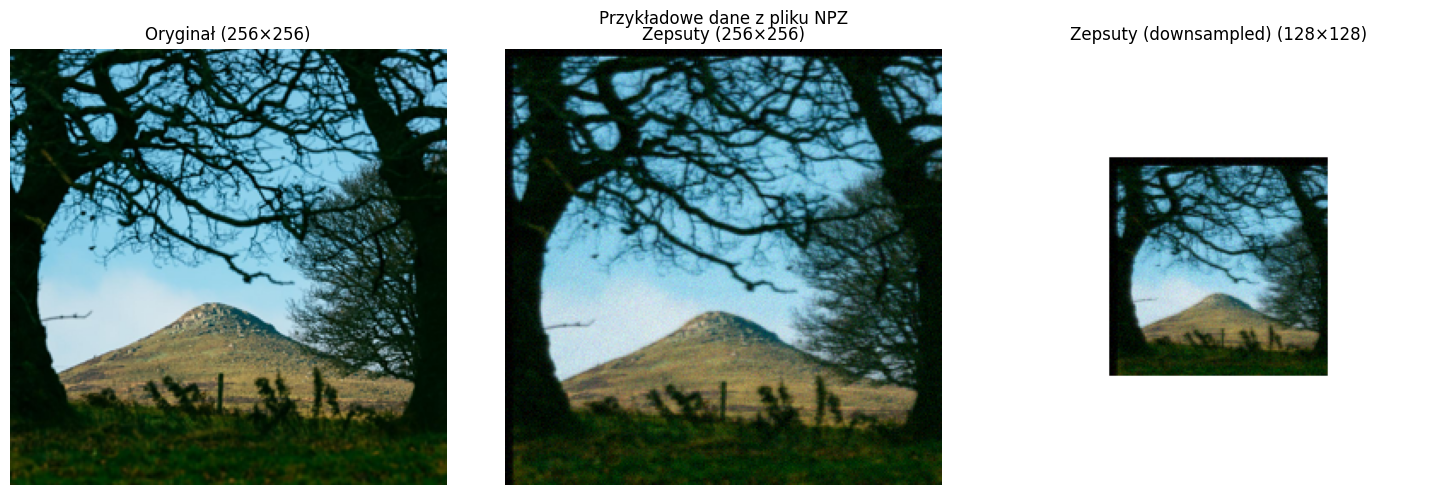

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    download_data()

    # Path to a single NPZ file with data (training + validation)
    NPZ_PATH = os.path.join('data', 'train_val.npz')

    # Load datasets from NPZ
    train_ds, val_ds = setup_data_from_npz(NPZ_PATH) # These variables will also be available during the final evaluation

    if train_ds is not None and val_ds is not None:
        print(f"Number of images in the training set: {len(train_ds)}")
        print(f"Number of images in the validation set: {len(val_ds)}")

        # Preview of sample data
        sample_for_show = val_ds[0]
        plot_results(sample_for_show['image_original'], sample_for_show['image_corrupted'], sample_for_show['image_corrupted_downsampled'], title="Sample data from the NPZ file", labels=("Original", "Corrupted", "Corrupted (downsampled)"))

## Your Solution
Below we present simplified solutions that serve as an example. These solutions achieve very poor results, but they demonstrate the response format we expect and can serve as a starting point for your implementation.

Your solution should be placed in this section. Make changes only here. The following functions will be submitted for evaluation:
- `compute_kernel() -> torch.Tensor`,
- `upsample(image: torch.Tensor) -> torch.Tensor`,
- `compute_kernel_upsampling(kernel_task1: torch.Tensor) -> torch.Tensor`

You can call additional helper functions within their context.

Previously prepared training and validation data are available in the `train_ds` and `val_ds` variables.

### Part 1 - Convolutional Kernel

In [ ]:
def compute_kernel() -> torch.Tensor:
    """
    Creates a 9x9 blur kernel.
    """
    kernel = torch.ones(9, 9, device=DEVICE) / 81
    return kernel

### Part 2 - Upsampling

In [ ]:
def upsample(image: torch.Tensor) -> torch.Tensor:
    """
    Simple upsampling using the "nearest neighbor" method
    to a size of 256x256.

    Idea:
    Each pixel from the smaller image is simply duplicated several times
    vertically and horizontally. This makes the image larger, but no
    new details appear – we only see the "stretched" original pixels.

    Args:
        image (torch.Tensor): An image in the format (C, h, w), where:
            - C is the number of channels (e.g., 3 for RGB),
            - h, w are the height and width of the image (≤ 256).

    Returns:
        torch.Tensor: An image with the shape (C, 256, 256) obtained by
        repeating the input's rows and columns enough times to cover
        the entire target size, and then cropping to the exact
        dimensions of 256x256.
    """
    assert image.dim() == 3, "Expecting a tensor with shape (C, h, w)."
    C, h, w = image.shape

    # Target dimensions.
    Ht, Wt = (256, 256)

    # How many times we need to repeat rows and columns to reach >= 256.
    rh = max(1, math.ceil(Ht / h))
    rw = max(1, math.ceil(Wt / w))

    # repeat_interleave duplicates consecutive rows/columns the appropriate number of times.
    y = image.repeat_interleave(rh, dim=1).repeat_interleave(rw, dim=2)

    # It might happen that there are "too many" repetitions – in that case, we crop to 256x256.
    return y[:, :Ht, :Wt]

In [ ]:
def compute_kernel_upsampling(kernel_task1: torch.Tensor) -> torch.Tensor:
    """
    During evaluation, the kernel from the first part will be passed
    as an argument. You can use it or ignore it.
    """
    return kernel_task1

## Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data.

Make sure before submitting that the entire notebook executes from start to finish without errors and without user intervention after executing the \`Run All\` command.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:

    # ============== 1) First part of the task ==============
    # -- Training
    your_kernel = compute_kernel()
    # -- Solution evaluation
    your_kernel_mse = evaluate_solution(your_kernel, val_ds)

    # ============== 2) Second part of the task ==============
    # -- Training
    your_kernel_upsampling = compute_kernel_upsampling(your_kernel)
    # -- Solution evaluation
    your_upsampling_mse = evaluate_solution(your_kernel_upsampling, val_ds, upsample)

    score, kernel_score, upsampling_score = compute_score(your_kernel_mse, your_upsampling_mse)

    print(f"MSE on the validation set (kernel): {your_kernel_mse:.4f}. Number of points (kernel): {kernel_score}")
    print(f"MSE on the validation set (upsampling): {your_upsampling_mse:.4f}. Number of points (upsampling): {upsampling_score}")
    print(f"Estimated number of points for the task: {score}")

    # Visualization of the kernel's operation on a single validation image.
    sample_for_show = val_ds[0]
    reconstructed = apply_kernel(sample_for_show['image_corrupted'].to(DEVICE), your_kernel.to(DEVICE))
    plot_results(sample_for_show['image_original'], sample_for_show['image_corrupted'], reconstructed, title="Visualization of your kernel's operation")

    # Preview of the kernel itself (color map).
    plt.figure(figsize=(5, 5))
    plt.imshow(your_kernel.cpu().detach().numpy(), cmap='viridis')
    plt.colorbar()
    plt.title("Your kernel")
    plt.show()

    # Visualization of the upsampling with the kernel on a single validation image.
    reconstructed = apply_kernel(upsample(sample_for_show['image_corrupted_downsampled'].to(DEVICE)), your_kernel_upsampling)
    plot_results(sample_for_show['image_original'], sample_for_show['image_corrupted_downsampled'], reconstructed, title="Visualization of your upsampling method with the kernel", labels=("Original", "Corrupted (downsampled)", "Reconstructed"))